#  [CVPR 2026] CV4CHL — Children Gait Challenge: Exploratory Data Analysis

**Workshop:** Computer Vision for Children @ CVPR 2026  
**Task:** Pediatric gait analysis — human pose & motion CV for clinical assessment  
**Dataset path:** `/kaggle/input/datasets/yusufmurtaza01/2026-cv4chl-dataset/dataset`

---

###  EDA Roadmap
1. **Dataset Structure** — File tree, formats, counts  
2. **Label / Metadata Inspection** — Class distribution, subject demographics  
3. **Skeleton Data Loading** — Keypoints structure, confidence scores  
4. **Temporal Coverage** — Sequence lengths, frame rates  
5. **Keypoint Statistics** — Joint-wise distributions, visibility  
6. **Gait Visualisation** — Skeleton overlays, motion trajectories  
7. **Joint Angle Features** — Derived biomechanical angles  
8. **Missing Data & Quality** — NaN audit, low-confidence frames  
9. **Train / Test Split Analysis** — Subject overlap, class balance  
10. **Key Takeaways & Modelling Hints**


## 0️⃣ Setup & Imports

In [1]:
import os, json, glob, re
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import seaborn as sns

# Optional but useful
try:
    import cv2
    HAS_CV2 = True
except ImportError:
    HAS_CV2 = False
    print("opencv-python not available — image-based cells will be skipped.")

try:
    from scipy import stats
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False

# Aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.facecolor": "white"
})

DATASET_ROOT = Path("/kaggle/input/datasets/yusufmurtaza01/2026-cv4chl-dataset/dataset")
print(f"Dataset root exists: {DATASET_ROOT.exists()}")
print(f"Root: {DATASET_ROOT}")

Dataset root exists: True
Root: /kaggle/input/datasets/yusufmurtaza01/2026-cv4chl-dataset/dataset


## 1️⃣ Dataset Structure

In [2]:
# ── Full directory tree (depth-limited) 

def print_tree(root: Path, prefix: str = "", depth: int = 0, max_depth: int = 4):
    if depth > max_depth:
        return
    try:
        entries = sorted(root.iterdir())
    except PermissionError:
        return
    dirs   = [e for e in entries if e.is_dir()]
    files  = [e for e in entries if e.is_file()]
    # summarise large flat dirs
    if len(files) > 12 and depth > 1:
        print(f"{prefix}├── [{len(files)} files]  "
              f"e.g. {', '.join(f.name for f in files[:4])} …")
    else:
        for f in files:
            print(f"{prefix}├── {f.name}  ({f.stat().st_size/1024:.1f} KB)")
    for d in dirs:
        print(f"{prefix}└── 📁 {d.name}/")
        print_tree(d, prefix + "    ", depth + 1, max_depth)

# print_tree(DATASET_ROOT)  # A massive amount of output will be displayed, uncomment to display the directory tree

Total files : 339,236
Total size  : 4924.2 MB

Extension breakdown:
  .json     339,236  ██████████████████████████████


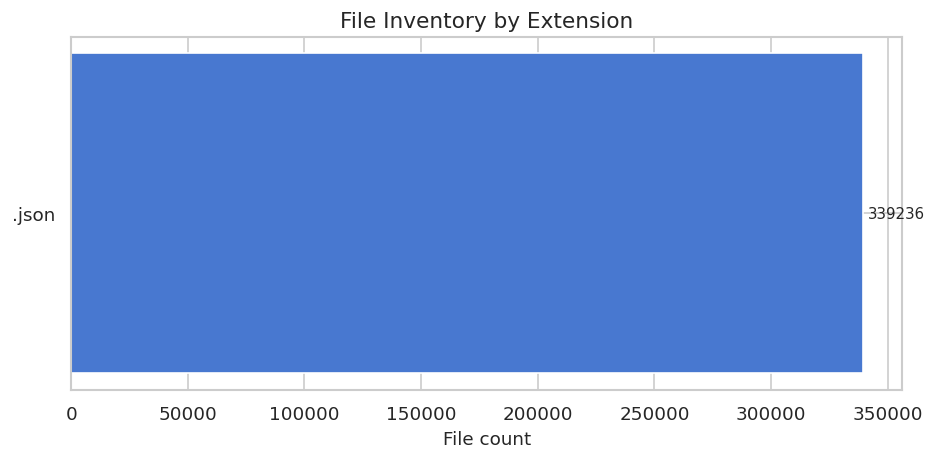

In [3]:
# ── File inventory by extension 

all_files = list(DATASET_ROOT.rglob("*"))
file_ext_counts = Counter(f.suffix.lower() for f in all_files if f.is_file())
total_files = sum(file_ext_counts.values())
total_size_mb = sum(f.stat().st_size for f in all_files if f.is_file()) / 1e6

print(f"Total files : {total_files:,}")
print(f"Total size  : {total_size_mb:.1f} MB")
print()
print("Extension breakdown:")
for ext, cnt in file_ext_counts.most_common():
    bar = "█" * int(30 * cnt / total_files)
    print(f"  {ext or '(no ext)':8s}  {cnt:6,}  {bar}")

# ── Bar chart 
fig, ax = plt.subplots(figsize=(8, 4))
exts, cnts = zip(*file_ext_counts.most_common(12))
colors = sns.color_palette("muted", len(exts))
bars = ax.barh(list(reversed(exts)), list(reversed(cnts)), color=list(reversed(colors)))
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("File count")
ax.set_title("File Inventory by Extension")
plt.tight_layout()
plt.show()

## 2️⃣ Label & Metadata Inspection

In [4]:
# ── Auto-discover CSV / JSON label files 

label_candidates = (
    list(DATASET_ROOT.glob("*.csv")) +
    list(DATASET_ROOT.glob("**/*.csv")) +
    list(DATASET_ROOT.glob("*.json")) +
    list(DATASET_ROOT.glob("*label*")) +
    list(DATASET_ROOT.glob("*annotation*")) +
    list(DATASET_ROOT.glob("*meta*"))
)
print("Candidate label / meta files:")
for p in label_candidates[:20]:
    print(f"  {p.relative_to(DATASET_ROOT)}")

Candidate label / meta files:


In [5]:
# ── Load the label CSV (adapt path as needed) 

# Common naming patterns:
csv_candidates = list(DATASET_ROOT.rglob("*.csv"))
dfs = {}
for cp in csv_candidates:
    try:
        df = pd.read_csv(cp)
        dfs[cp.name] = df
        print(f"  {cp.relative_to(DATASET_ROOT)}  →  shape {df.shape}")
        print(f"    columns: {list(df.columns)}")
        print()
    except Exception as e:
        print(f"  {cp.name}: {e}")

In [6]:
# ── Inspect the primary label dataframe 
# Adjust 'label_df' to the correct key from `dfs` above

if dfs:
    key = list(dfs.keys())[0]   # ← change to correct file if needed
    label_df = dfs[key]
    display(label_df.head(10))
    print("\nData types:")
    display(label_df.dtypes.to_frame("dtype"))
    print("\nNull counts:")
    display(label_df.isnull().sum().to_frame("nulls"))
else:
    print("No CSV found — will infer labels from directory names below.")
    label_df = None

No CSV found — will infer labels from directory names below.


In [7]:
# ── Class / condition distribution 

# Try common column names for the target label
TARGET_COL_CANDIDATES = [
    "label", "condition", "class", "diagnosis", "category",
    "disease", "status", "group", "disorder"
]

target_col = None
if label_df is not None:
    for c in label_df.columns:
        if c.lower() in TARGET_COL_CANDIDATES or "label" in c.lower():
            target_col = c
            break

if target_col:
    vc = label_df[target_col].value_counts()
    print(f"Target column: '{target_col}'")
    print(vc)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Bar
    colors = sns.color_palette("Set2", len(vc))
    axes[0].bar(vc.index.astype(str), vc.values, color=colors)
    axes[0].set_title("Class Distribution (Count)")
    axes[0].set_xlabel("Class")
    axes[0].set_ylabel("Count")
    for i, v in enumerate(vc.values):
        axes[0].text(i, v + 0.3, str(v), ha="center", fontsize=9)

    # Pie
    axes[1].pie(vc.values, labels=vc.index.astype(str),
                autopct="%1.1f%%", colors=colors, startangle=90)
    axes[1].set_title("Class Distribution (Proportion)")

    plt.suptitle("Target Label Distribution", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Could not auto-detect target column — check column names.")
    if label_df is not None:
        print("Available columns:", list(label_df.columns))

Could not auto-detect target column — check column names.


In [8]:
# ── Subject / patient demographics 
if label_df is not None:
    demo_cols = [c for c in label_df.columns
                 if any(k in c.lower() for k in ["age", "sex", "gender",
                                                   "height", "weight", "subject",
                                                   "patient", "id"])]
    if demo_cols:
        print("Demographic columns found:", demo_cols)
        display(label_df[demo_cols].describe(include="all"))

        n_demo = len(demo_cols)
        fig, axes = plt.subplots(1, n_demo, figsize=(5 * n_demo, 4))
        if n_demo == 1:
            axes = [axes]
        for ax, col in zip(axes, demo_cols):
            if label_df[col].dtype in [object, "category"] or label_df[col].nunique() < 15:
                vc2 = label_df[col].value_counts()
                ax.bar(vc2.index.astype(str), vc2.values,
                       color=sns.color_palette("pastel", len(vc2)))
                ax.set_title(col)
            else:
                ax.hist(label_df[col].dropna(), bins=20,
                        color="#4C72B0", edgecolor="white")
                ax.set_title(col)
                ax.set_xlabel(col)
        plt.tight_layout()
        plt.show()
    else:
        print("No demographic columns detected.")

## 3️⃣ Skeleton / Keypoint Data Loading

In [9]:
# ── Discover pose/skeleton files 

json_files  = sorted(DATASET_ROOT.rglob("*.json"))
npy_files   = sorted(DATASET_ROOT.rglob("*.npy"))
npz_files   = sorted(DATASET_ROOT.rglob("*.npz"))
csv_pose    = [f for f in DATASET_ROOT.rglob("*.csv")
               if any(k in f.name.lower() for k in
                      ["pose", "keypoint", "skeleton", "joint", "kp"])]

print(f"JSON files : {len(json_files):,}")
print(f"NPY files  : {len(npy_files):,}")
print(f"NPZ files  : {len(npz_files):,}")
print(f"Pose CSVs  : {len(csv_pose):,}")

# Show a few paths
for lst, lbl in [(json_files, "JSON"), (npy_files, "NPY"), (npz_files, "NPZ")]:
    if lst:
        print(f"\nFirst 5 {lbl}:")
        for p in lst[:5]:
            print(f"  {p.relative_to(DATASET_ROOT)}")

JSON files : 339,236
NPY files  : 0
NPZ files  : 0
Pose CSVs  : 0

First 5 JSON:
  0001/0001-0001_backward_203-514_filtered_pose/frame_00000000.json
  0001/0001-0001_backward_203-514_filtered_pose/frame_00000001.json
  0001/0001-0001_backward_203-514_filtered_pose/frame_00000002.json
  0001/0001-0001_backward_203-514_filtered_pose/frame_00000003.json
  0001/0001-0001_backward_203-514_filtered_pose/frame_00000004.json


In [10]:
# ── Peek at one JSON file 

def load_sample_json(json_files, n=1):
    for path in json_files[:n]:
        print(f"File: {path.relative_to(DATASET_ROOT)}")
        with open(path) as f:
            data = json.load(f)
        # Pretty-print structure (truncated)
        def summarise(obj, depth=0):
            pad = "  " * depth
            if isinstance(obj, dict):
                print(f"{pad}dict with keys: {list(obj.keys())}")
                for k, v in list(obj.items())[:6]:
                    print(f"{pad}  [{k}]:")
                    summarise(v, depth + 2)
            elif isinstance(obj, list):
                print(f"{pad}list[{len(obj)}]")
                if obj:
                    summarise(obj[0], depth + 2)
            elif isinstance(obj, (int, float)):
                print(f"{pad}{obj}")
            else:
                print(f"{pad}{type(obj).__name__}: {str(obj)[:80]}")
        summarise(data)
        print()
        return data

if json_files:
    sample_json = load_sample_json(json_files)
else:
    sample_json = None
    print("No JSON files found.")

File: 0001/0001-0001_backward_203-514_filtered_pose/frame_00000000.json
dict with keys: ['instance_info', 'video_info', 'frame_index']
  [instance_info]:
    list[1]
        dict with keys: ['keypoints', 'keypoint_scores', 'obj_id', 'gt_bbox_xywh_px']
          [keypoints]:
            list[133]
                list[2]
                    910.6859160179556
          [keypoint_scores]:
            list[133]
                0.816247284412384
          [obj_id]:
            2
          [gt_bbox_xywh_px]:
            list[4]
                681
  [video_info]:
    dict with keys: ['video_name', 'width', 'height', 'fps', 'total_frames']
      [video_name]:
        str: 0001-0001_backward_203-514.mp4
      [width]:
        1920
      [height]:
        1080
      [fps]:
        59
      [total_frames]:
        312
  [frame_index]:
    0



In [11]:
# ── Peek at one NPY / NPZ file 

if npy_files:
    arr = np.load(npy_files[0], allow_pickle=True)
    print(f"NPY file : {npy_files[0].relative_to(DATASET_ROOT)}")
    print(f"Shape    : {arr.shape}")
    print(f"Dtype    : {arr.dtype}")
    print(f"Min/Max  : {arr.min():.4f} / {arr.max():.4f}")
    print(f"Sample   :\n{arr[:3]}")

if npz_files:
    data = np.load(npz_files[0], allow_pickle=True)
    print(f"\nNPZ file: {npz_files[0].relative_to(DATASET_ROOT)}")
    print(f"Keys    : {list(data.keys())}")
    for k in list(data.keys())[:4]:
        v = data[k]
        print(f"  {k}: shape={v.shape}, dtype={v.dtype}")

In [12]:
# ── Keypoint schema: COCO-Wholebody 133 (actual dataset format) ─────────────
# Body: 0-16  |  Feet: 17-22  |  Face: 23-90  |  Hands: 91-132

COCO_WHOLEBODY_133 = [
    # 0-16  Body
    "nose","left_eye","right_eye","left_ear","right_ear",
    "left_shoulder","right_shoulder","left_elbow","right_elbow",
    "left_wrist","right_wrist","left_hip","right_hip",
    "left_knee","right_knee","left_ankle","right_ankle",
    # 17-22  Feet
    "left_big_toe","left_small_toe","left_heel",
    "right_big_toe","right_small_toe","right_heel",
    # 23-90  Face (68 landmarks)
    *[f"face_{i:02d}" for i in range(68)],
    # 91-132  Hands (21 left + 21 right)
    *[f"left_hand_{i:02d}" for i in range(21)],
    *[f"right_hand_{i:02d}" for i in range(21)],
]

# Body + feet skeleton edges (indices into COCO_WHOLEBODY_133)
BODY_SKELETON = [
    (0,1),(0,2),(1,3),(2,4),                          # face
    (5,6),(5,7),(7,9),(6,8),(8,10),                   # arms
    (5,11),(6,12),(11,12),                             # torso
    (11,13),(13,15),(12,14),(14,16),                   # legs
    (15,17),(15,18),(15,19),                           # left foot
    (16,20),(16,21),(16,22),                           # right foot
]

print(f"COCO-Wholebody schema: {len(COCO_WHOLEBODY_133)} keypoints")
print(f"  Body  (0-16) : {COCO_WHOLEBODY_133[:17]}")
print(f"  Feet  (17-22): {COCO_WHOLEBODY_133[17:23]}")
print(f"  Face  (23-90): {len(COCO_WHOLEBODY_133[23:91])} joints")
print(f"  Hands (91-132): {len(COCO_WHOLEBODY_133[91:])} joints")


COCO-Wholebody schema: 133 keypoints
  Body  (0-16) : ['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear', 'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow', 'left_wrist', 'right_wrist', 'left_hip', 'right_hip', 'left_knee', 'right_knee', 'left_ankle', 'right_ankle']
  Feet  (17-22): ['left_big_toe', 'left_small_toe', 'left_heel', 'right_big_toe', 'right_small_toe', 'right_heel']
  Face  (23-90): 68 joints
  Hands (91-132): 42 joints


## 4️⃣ Temporal Coverage — Sequence Lengths & Frame Rates

Sequences found : 1185
Frames — min: 39, max: 2765, mean: 286.3, median: 226


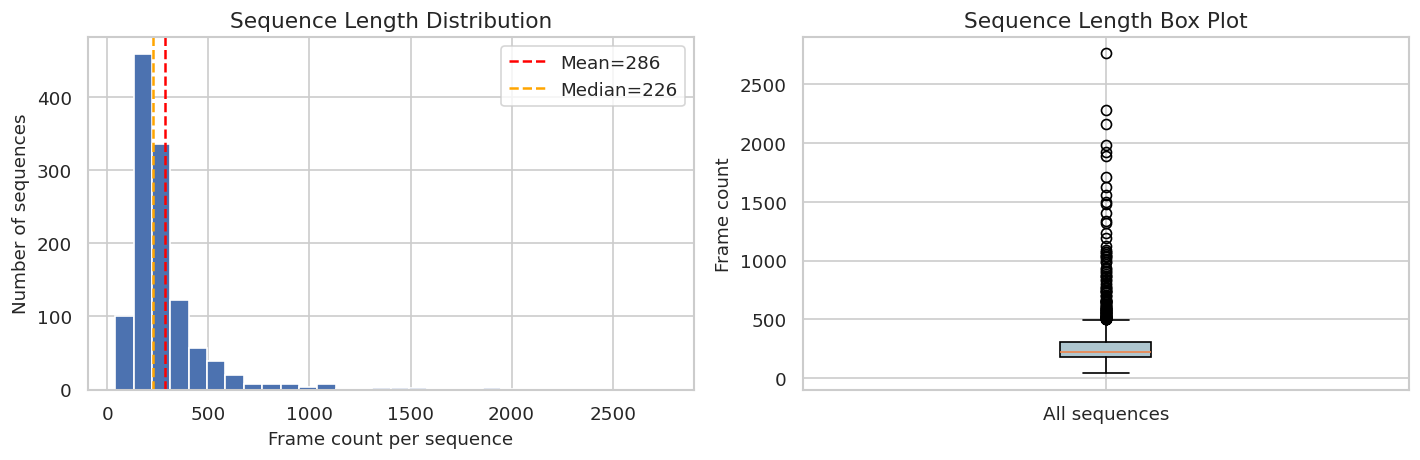

In [13]:
# ── Count frames per sequence (each folder = one gait trial) 

# Pattern A: one JSON per frame inside a subject/trial folder
seq_frame_counts = {}
for trial_dir in sorted(DATASET_ROOT.rglob("*")):
    if not trial_dir.is_dir():
        continue
    frames = list(trial_dir.glob("*.json"))
    if frames:
        seq_frame_counts[str(trial_dir.relative_to(DATASET_ROOT))] = len(frames)

# Pattern B: NPY arrays where first dim = frames
if not seq_frame_counts and npy_files:
    for nf in npy_files[:200]:
        arr = np.load(nf, allow_pickle=True)
        seq_frame_counts[str(nf.relative_to(DATASET_ROOT))] = arr.shape[0]

if seq_frame_counts:
    lengths = list(seq_frame_counts.values())
    print(f"Sequences found : {len(lengths)}")
    print(f"Frames — min: {min(lengths)}, max: {max(lengths)}, "
          f"mean: {np.mean(lengths):.1f}, median: {np.median(lengths):.0f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    axes[0].hist(lengths, bins=30, color="#4C72B0", edgecolor="white")
    axes[0].axvline(np.mean(lengths), color="red", linestyle="--",
                    label=f"Mean={np.mean(lengths):.0f}")
    axes[0].axvline(np.median(lengths), color="orange", linestyle="--",
                    label=f"Median={np.median(lengths):.0f}")
    axes[0].set_xlabel("Frame count per sequence")
    axes[0].set_ylabel("Number of sequences")
    axes[0].set_title("Sequence Length Distribution")
    axes[0].legend()

    # Box plot
    axes[1].boxplot(lengths, vert=True, patch_artist=True,
                    boxprops=dict(facecolor="#AEC6CF"))
    axes[1].set_ylabel("Frame count")
    axes[1].set_title("Sequence Length Box Plot")
    axes[1].set_xticks([1])
    axes[1].set_xticklabels(["All sequences"])

    plt.tight_layout()
    plt.show()
else:
    print("Could not determine sequence structure — check folder layout.")

In [14]:
# ── Sequence length by class ─────────────────────────────────────────────────
# If label_df has sequence IDs and target_col is known

if label_df is not None and target_col and seq_frame_counts:
    # Try to link sequence path/name to a subject ID in label_df
    id_col_candidates = [c for c in label_df.columns
                         if any(k in c.lower() for k in ["id","name","file","seq","subject","trial"])]
    if id_col_candidates:
        id_col = id_col_candidates[0]
        print(f"Linking on column: '{id_col}'")

        seq_df = pd.DataFrame({
            "seq_path": list(seq_frame_counts.keys()),
            "n_frames" : list(seq_frame_counts.values())
        })
        # Join on partial match
        def match_id(path, label_ids):
            for lid in label_ids:
                if str(lid) in path:
                    return lid
            return None
        seq_df["matched_id"] = seq_df["seq_path"].apply(
            lambda p: match_id(p, label_df[id_col].astype(str).tolist())
        )
        merged = seq_df.dropna(subset=["matched_id"]).merge(
            label_df[[id_col, target_col]].rename(columns={id_col: "matched_id"}),
            on="matched_id", how="left"
        )
        if not merged.empty:
            fig, ax = plt.subplots(figsize=(9, 4))
            groups = [grp["n_frames"].values
                      for _, grp in merged.groupby(target_col)]
            labels_box = [str(k) for k in merged[target_col].unique()]
            bp = ax.boxplot(groups, patch_artist=True, labels=labels_box)
            colors_box = sns.color_palette("Set2", len(groups))
            for patch, col in zip(bp["boxes"], colors_box):
                patch.set_facecolor(col)
            ax.set_xlabel("Class")
            ax.set_ylabel("Frame count")
            ax.set_title("Sequence Length per Class")
            plt.tight_layout()
            plt.show()
        else:
            print("Could not merge sequences with labels.")
    else:
        print("No sequence-ID column found in label_df.")


## 5️⃣ Keypoint Statistics

In [15]:
# ── Build keypoint matrix — fixed for CV4CHL JSON format ────────────────────
# Actual format:
#   data['instance_info'][0]['keypoints']       = [[x,y], ...]  (133 joints)
#   data['instance_info'][0]['keypoint_scores'] = [s, ...]       (133 scores)
# Output matrix shape: (N_frames, 133, 3)  →  x, y, confidence

MAX_SAMPLES = 500

def parse_frame_json(data: dict):
    instances = data.get('instance_info', [])
    if not instances:
        return None
    person  = instances[0]                             # first / only person
    kps_xy  = person.get('keypoints', [])              # list of [x, y]
    scores  = person.get('keypoint_scores', [])        # list of float
    if not kps_xy or not scores or len(kps_xy) != len(scores):
        return None
    n   = len(kps_xy)
    arr = np.zeros((n, 3), dtype=np.float32)
    for i, (xy, s) in enumerate(zip(kps_xy, scores)):
        arr[i, 0] = float(xy[0])
        arr[i, 1] = float(xy[1])
        arr[i, 2] = float(s)
    return arr   # (N_joints, 3)

# ── Sample and stack ─────────────────────────────────────────────────────────
sample_json_files = json_files[:MAX_SAMPLES]
all_kp_frames = []

for jf in sample_json_files:
    try:
        with open(jf) as f:
            data = json.load(f)
        parsed = parse_frame_json(data)
        if parsed is not None:
            all_kp_frames.append(parsed)
    except Exception:
        pass

if all_kp_frames:
    kp_matrix = np.stack(all_kp_frames, axis=0)  # (N_frames, N_joints, 3)
    N_JOINTS  = kp_matrix.shape[1]
    if N_JOINTS == 133:
        KP_NAMES = COCO_WHOLEBODY_133
        SKELETON = BODY_SKELETON
    elif N_JOINTS == 17:
        KP_NAMES = COCO_WHOLEBODY_133[:17]
        SKELETON = BODY_SKELETON[:16]
    else:
        KP_NAMES = [f'j{i}' for i in range(N_JOINTS)]
        SKELETON = []
    print(f'Keypoint matrix shape: {kp_matrix.shape}')
    print(f'  Frames  : {kp_matrix.shape[0]}')
    print(f'  Joints  : {kp_matrix.shape[1]}  (schema: {KP_NAMES[0]} ... {KP_NAMES[-1]})')
    print(f'  Channels: {kp_matrix.shape[2]}  (x, y, confidence)')
    print(f'\nConf mean={kp_matrix[:,:,2].mean():.3f}  '
          f'min={kp_matrix[:,:,2].min():.3f}  max={kp_matrix[:,:,2].max():.3f}')
else:
    kp_matrix = None
    KP_NAMES  = []
    SKELETON  = []
    print('No parseable keypoints found — check JSON structure.')


Keypoint matrix shape: (500, 133, 3)
  Frames  : 500
  Joints  : 133  (schema: nose ... right_hand_20)
  Channels: 3  (x, y, confidence)

Conf mean=0.774  min=0.136  max=1.149


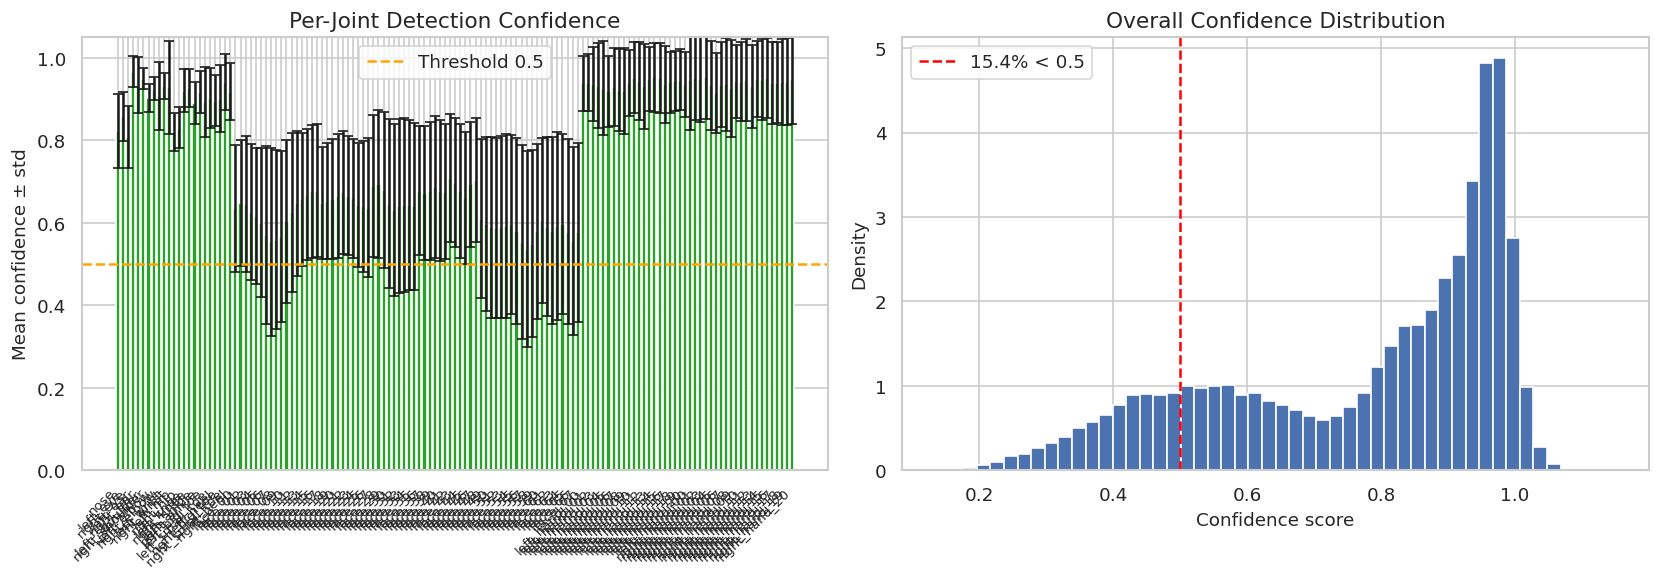

In [16]:
# ── Confidence score distributions 

if kp_matrix is not None:
    conf = kp_matrix[:, :, 2]   # (N_frames, N_joints)
    mean_conf = conf.mean(axis=0)
    std_conf  = conf.std(axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Per-joint mean confidence
    colors_conf = ["#d62728" if c < 0.5 else "#2ca02c" for c in mean_conf]
    axes[0].bar(range(len(KP_NAMES)), mean_conf, color=colors_conf,
                yerr=std_conf, capsize=3)
    axes[0].set_xticks(range(len(KP_NAMES)))
    axes[0].set_xticklabels(KP_NAMES, rotation=45, ha="right", fontsize=8)
    axes[0].set_ylim(0, 1.05)
    axes[0].axhline(0.5, color="orange", linestyle="--", label="Threshold 0.5")
    axes[0].set_ylabel("Mean confidence ± std")
    axes[0].set_title("Per-Joint Detection Confidence")
    axes[0].legend()

    # Overall confidence histogram
    axes[1].hist(conf.flatten(), bins=50, color="#4C72B0", edgecolor="white",
                 density=True)
    axes[1].set_xlabel("Confidence score")
    axes[1].set_ylabel("Density")
    axes[1].set_title("Overall Confidence Distribution")

    pct_low = (conf.flatten() < 0.5).mean() * 100
    axes[1].axvline(0.5, color="red", linestyle="--",
                    label=f"{pct_low:.1f}% < 0.5")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_16/1046337974.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', N_BODY)


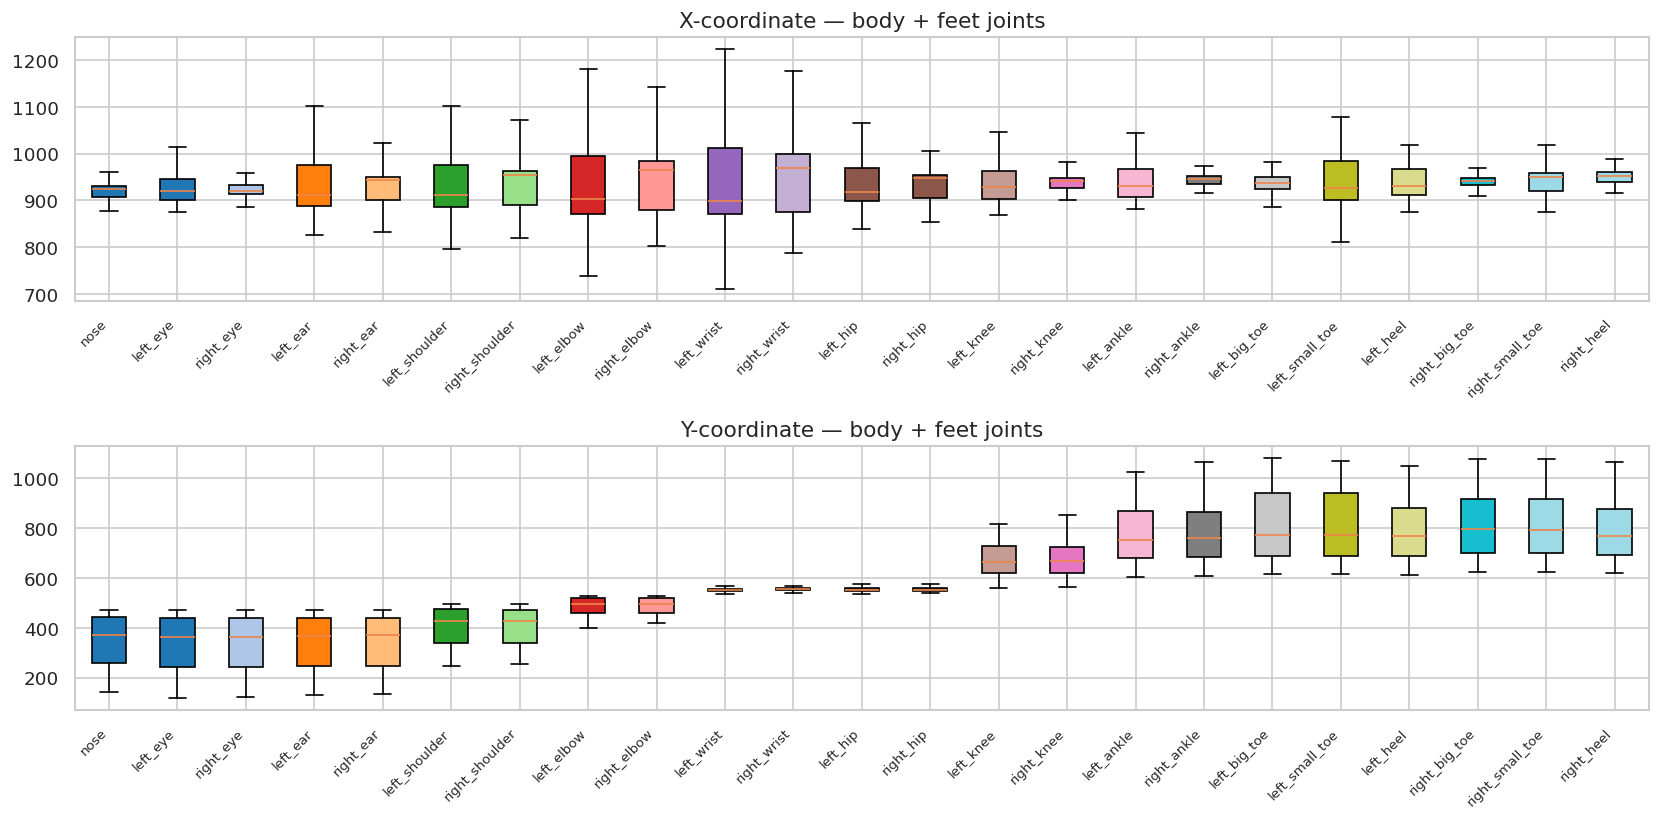

In [17]:
# ── Coordinate statistics per joint (body + feet joints 0-22) ───────────────

if kp_matrix is not None and kp_matrix.shape[1] > 0:
    # Limit to body+feet joints — 133 columns would be unreadable
    N_BODY     = min(23, kp_matrix.shape[1])
    x_coords   = kp_matrix[:, :N_BODY, 0]
    y_coords   = kp_matrix[:, :N_BODY, 1]
    plot_labels = KP_NAMES[:N_BODY]

    # Matplotlib >= 3.9 renamed 'labels' -> 'tick_labels' in boxplot()
    import matplotlib
    _mpl = tuple(int(v) for v in matplotlib.__version__.split('.')[:2])
    _lkw = 'tick_labels' if _mpl >= (3, 9) else 'labels'

    fig, axes = plt.subplots(2, 1, figsize=(14, 7))
    bp_x = axes[0].boxplot(x_coords, patch_artist=True, notch=False,
                            **{_lkw: plot_labels}, showfliers=False)
    bp_y = axes[1].boxplot(y_coords, patch_artist=True, notch=False,
                            **{_lkw: plot_labels}, showfliers=False)

    cmap = cm.get_cmap('tab20', N_BODY)
    for i, (bx, by) in enumerate(zip(bp_x['boxes'], bp_y['boxes'])):
        bx.set_facecolor(cmap(i))
        by.set_facecolor(cmap(i))

    for ax, title in zip(axes, ['X-coordinate — body + feet joints',
                                  'Y-coordinate — body + feet joints']):
        ax.set_title(title)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        plt.setp(ax.get_xticklabels(), ha='right')

    plt.tight_layout()
    plt.show()
elif kp_matrix is not None:
    print('kp_matrix has 0 joints — check parse_frame_json.')


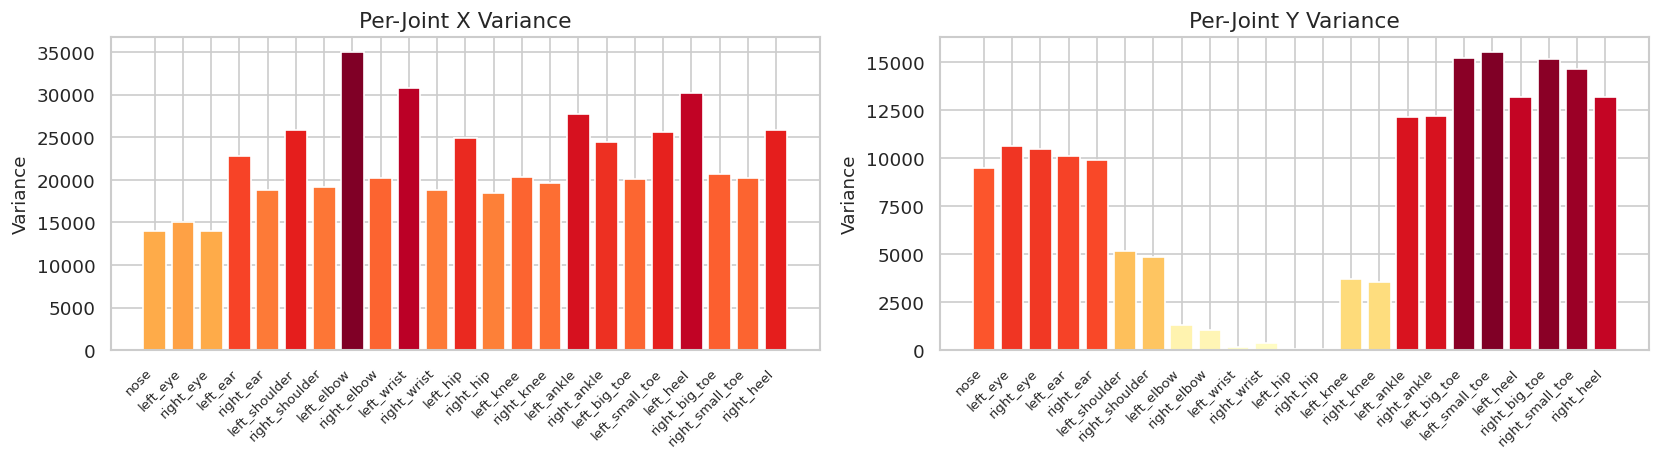


Top-5 most variable joints (X): ['left_elbow', 'left_wrist', 'left_heel', 'left_ankle', 'right_heel']
Top-5 most variable joints (Y): ['left_small_toe', 'left_big_toe', 'right_big_toe', 'right_small_toe', 'right_heel']


In [18]:
# ── Heatmap: joint coordinate variance

if kp_matrix is not None:
    N_BODY      = x_coords.shape[1]          # actual columns in x_coords / y_coords
    body_names  = KP_NAMES[:N_BODY]          # matching label slice
    var_x = x_coords.var(axis=0)
    var_y = y_coords.var(axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for ax, var, label in zip(axes, [var_x, var_y], ["X Variance", "Y Variance"]):
        ax.bar(range(N_BODY), var,
               color=plt.cm.YlOrRd(var / (var.max() + 1e-9)))
        ax.set_xticks(range(N_BODY))
        ax.set_xticklabels(body_names, rotation=45, ha="right", fontsize=8)
        ax.set_ylabel("Variance")
        ax.set_title(f"Per-Joint {label}")

    plt.tight_layout()
    plt.show()
    print("\nTop-5 most variable joints (X):",
          [body_names[i] for i in np.argsort(var_x)[::-1][:5]])
    print("Top-5 most variable joints (Y):",
          [body_names[i] for i in np.argsort(var_y)[::-1][:5]])

## 6️⃣ Gait Visualisation — Skeleton & Trajectories

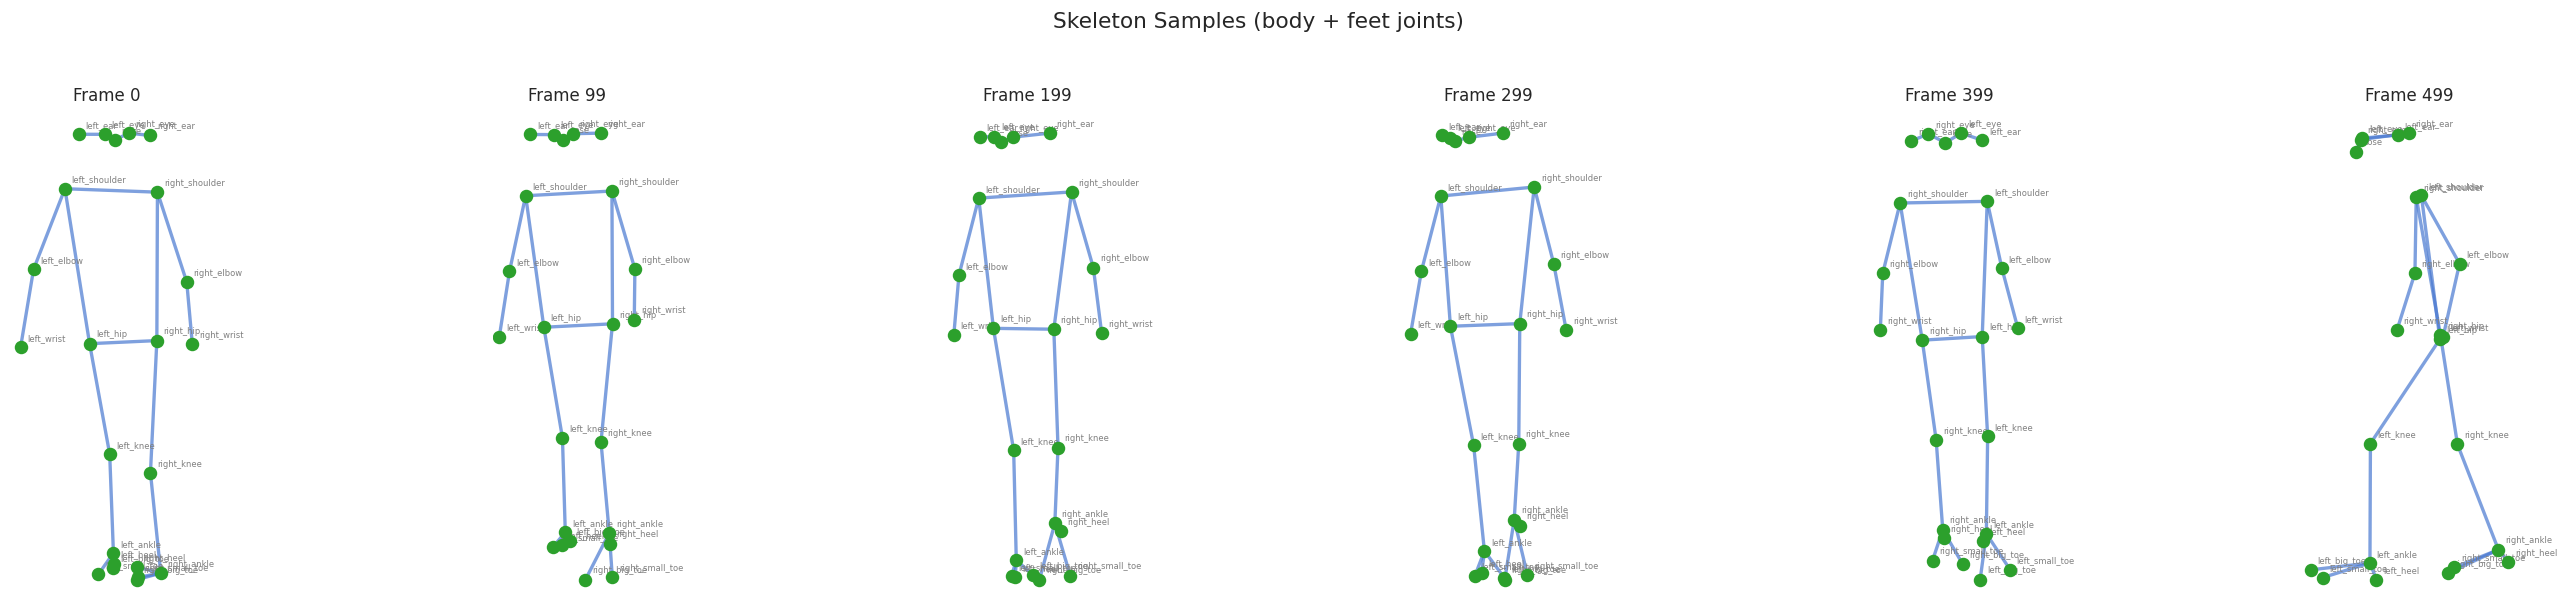

In [19]:
# ── Draw skeleton for a single frame (body + feet joints only) ──────────────

def draw_skeleton(ax, kps, skeleton_edges, kp_names=None,
                  title='', conf_thresh=0.3, n_body=23):
    n_plot = min(n_body, len(kps))
    x, y, conf = kps[:n_plot, 0], kps[:n_plot, 1], kps[:n_plot, 2]
    for (i, j) in skeleton_edges:
        if i < n_plot and j < n_plot and conf[i] > conf_thresh and conf[j] > conf_thresh:
            ax.plot([x[i], x[j]], [y[i], y[j]], 'b-', lw=2, alpha=0.7)
    for xi, yi, ci in zip(x, y, conf):
        if ci > conf_thresh:
            ax.scatter(xi, yi, c='#2ca02c' if ci > 0.5 else '#ff7f0e', s=50, zorder=5)
    if kp_names:
        for xi, yi, ci, name in zip(x, y, conf, kp_names[:n_plot]):
            if ci > conf_thresh:
                ax.annotate(name, (xi, yi), textcoords='offset points',
                            xytext=(4, 4), fontsize=5, color='gray')
    ax.set_title(title, fontsize=10)
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.axis('off')

if kp_matrix is not None and len(kp_matrix) > 0 and kp_matrix.shape[1] > 0:
    n_frames   = min(len(all_kp_frames), 6)
    sample_idx = np.linspace(0, len(all_kp_frames)-1, n_frames, dtype=int)
    fig, axes  = plt.subplots(1, n_frames, figsize=(4*n_frames, 5))
    if n_frames == 1: axes = [axes]
    for ax, fi in zip(axes, sample_idx):
        draw_skeleton(ax, kp_matrix[fi], SKELETON, KP_NAMES, title=f'Frame {fi}')
    plt.suptitle('Skeleton Samples (body + feet joints)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No skeleton to plot.')


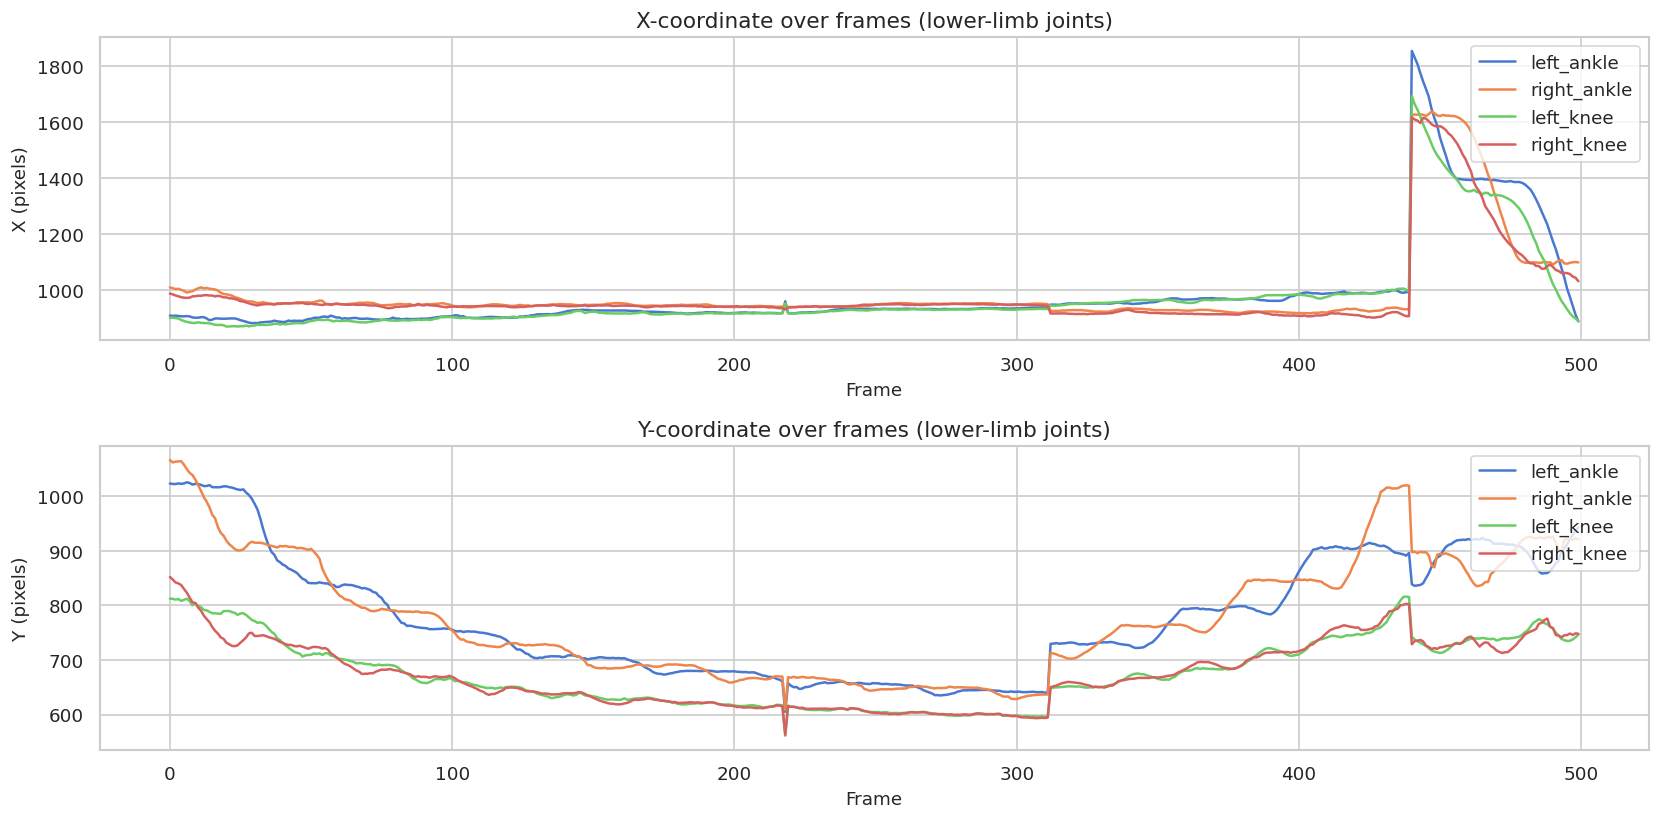

In [20]:
# ── Joint trajectory over time (one trial) 

if kp_matrix is not None and len(kp_matrix) >= 10:
    key_joints_for_traj = ["left_ankle", "right_ankle", "left_knee", "right_knee"]
    kj_idx = [KP_NAMES.index(k) for k in key_joints_for_traj if k in KP_NAMES]

    if kj_idx:
        frames = np.arange(len(kp_matrix))
        fig, axes = plt.subplots(2, 1, figsize=(14, 7))

        for idx, name in zip(kj_idx, key_joints_for_traj):
            axes[0].plot(frames, kp_matrix[:, idx, 0], label=name)
            axes[1].plot(frames, kp_matrix[:, idx, 1], label=name)

        axes[0].set_title("X-coordinate over frames (lower-limb joints)")
        axes[0].set_xlabel("Frame")
        axes[0].set_ylabel("X (pixels)")
        axes[0].legend(loc="upper right")

        axes[1].set_title("Y-coordinate over frames (lower-limb joints)")
        axes[1].set_xlabel("Frame")
        axes[1].set_ylabel("Y (pixels)")
        axes[1].legend(loc="upper right")

        plt.tight_layout()
        plt.show()

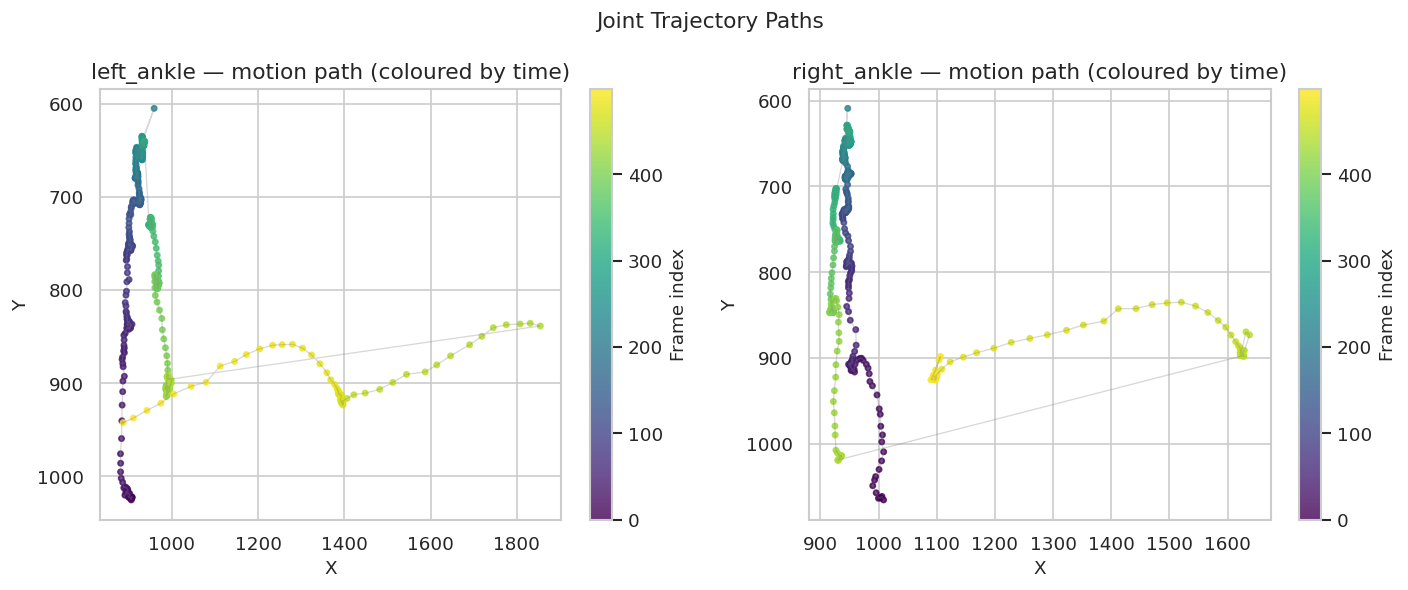

In [21]:
# ── 2-D joint trajectory scatter (path tracing) 

if kp_matrix is not None and len(kp_matrix) >= 10:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, joint_name in zip(axes, ["left_ankle", "right_ankle"]):
        if joint_name not in KP_NAMES:
            ax.set_visible(False)
            continue
        ji = KP_NAMES.index(joint_name)
        xs = kp_matrix[:, ji, 0]
        ys = kp_matrix[:, ji, 1]
        conf = kp_matrix[:, ji, 2]
        # colour by frame index
        sc = ax.scatter(xs, ys, c=np.arange(len(xs)),
                        cmap="viridis", s=10, alpha=0.8)
        ax.plot(xs, ys, color="gray", alpha=0.3, lw=0.8)
        ax.invert_yaxis()
        ax.set_title(f"{joint_name} — motion path (coloured by time)")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        plt.colorbar(sc, ax=ax, label="Frame index")

    plt.suptitle("Joint Trajectory Paths", fontsize=13)
    plt.tight_layout()
    plt.show()

## 7️⃣ Derived Biomechanical Features — Joint Angles

In [22]:
# ── Biomechanical joint angles from COCO-Wholebody keypoints ────────────────

def joint_angle(a, b, c):
    ba = a - b;  bc = c - b
    cos_a = (ba * bc).sum(axis=-1) / (
        np.linalg.norm(ba, axis=-1) * np.linalg.norm(bc, axis=-1) + 1e-9)
    return np.degrees(np.arccos(np.clip(cos_a, -1, 1)))

angle_results = {}

if kp_matrix is not None and kp_matrix.shape[1] > 0:
    xy = kp_matrix[:, :, :2]

    def get_j(name):
        return xy[:, KP_NAMES.index(name)] if name in KP_NAMES else None

    for side, abbr in [('left','L'), ('right','R')]:
        hip, knee, ankle = get_j(f'{side}_hip'), get_j(f'{side}_knee'), get_j(f'{side}_ankle')
        if all(v is not None for v in [hip, knee, ankle]):
            angle_results[f'{abbr} Knee Flexion']  = joint_angle(hip, knee, ankle)
        shoulder = get_j(f'{side}_shoulder')
        if all(v is not None for v in [shoulder, hip, knee]):
            angle_results[f'{abbr} Hip Flexion']   = joint_angle(shoulder, hip, knee)
        big_toe = get_j(f'{side}_big_toe')
        if all(v is not None for v in [knee, ankle, big_toe]):
            angle_results[f'{abbr} Ankle Dorsiflexion'] = joint_angle(knee, ankle, big_toe)

    print(f'Computed {len(angle_results)} joint angles:')
    for name, arr in angle_results.items():
        print(f'  {name:30s}  mean={arr.mean():.1f}deg  std={arr.std():.1f}deg')
else:
    print('No kp_matrix — skipping angles.')


Computed 6 joint angles:
  L Knee Flexion                  mean=170.7deg  std=14.5deg
  L Hip Flexion                   mean=174.7deg  std=7.4deg
  L Ankle Dorsiflexion            mean=148.5deg  std=24.7deg
  R Knee Flexion                  mean=172.7deg  std=8.9deg
  R Hip Flexion                   mean=175.2deg  std=5.8deg
  R Ankle Dorsiflexion            mean=145.5deg  std=23.1deg


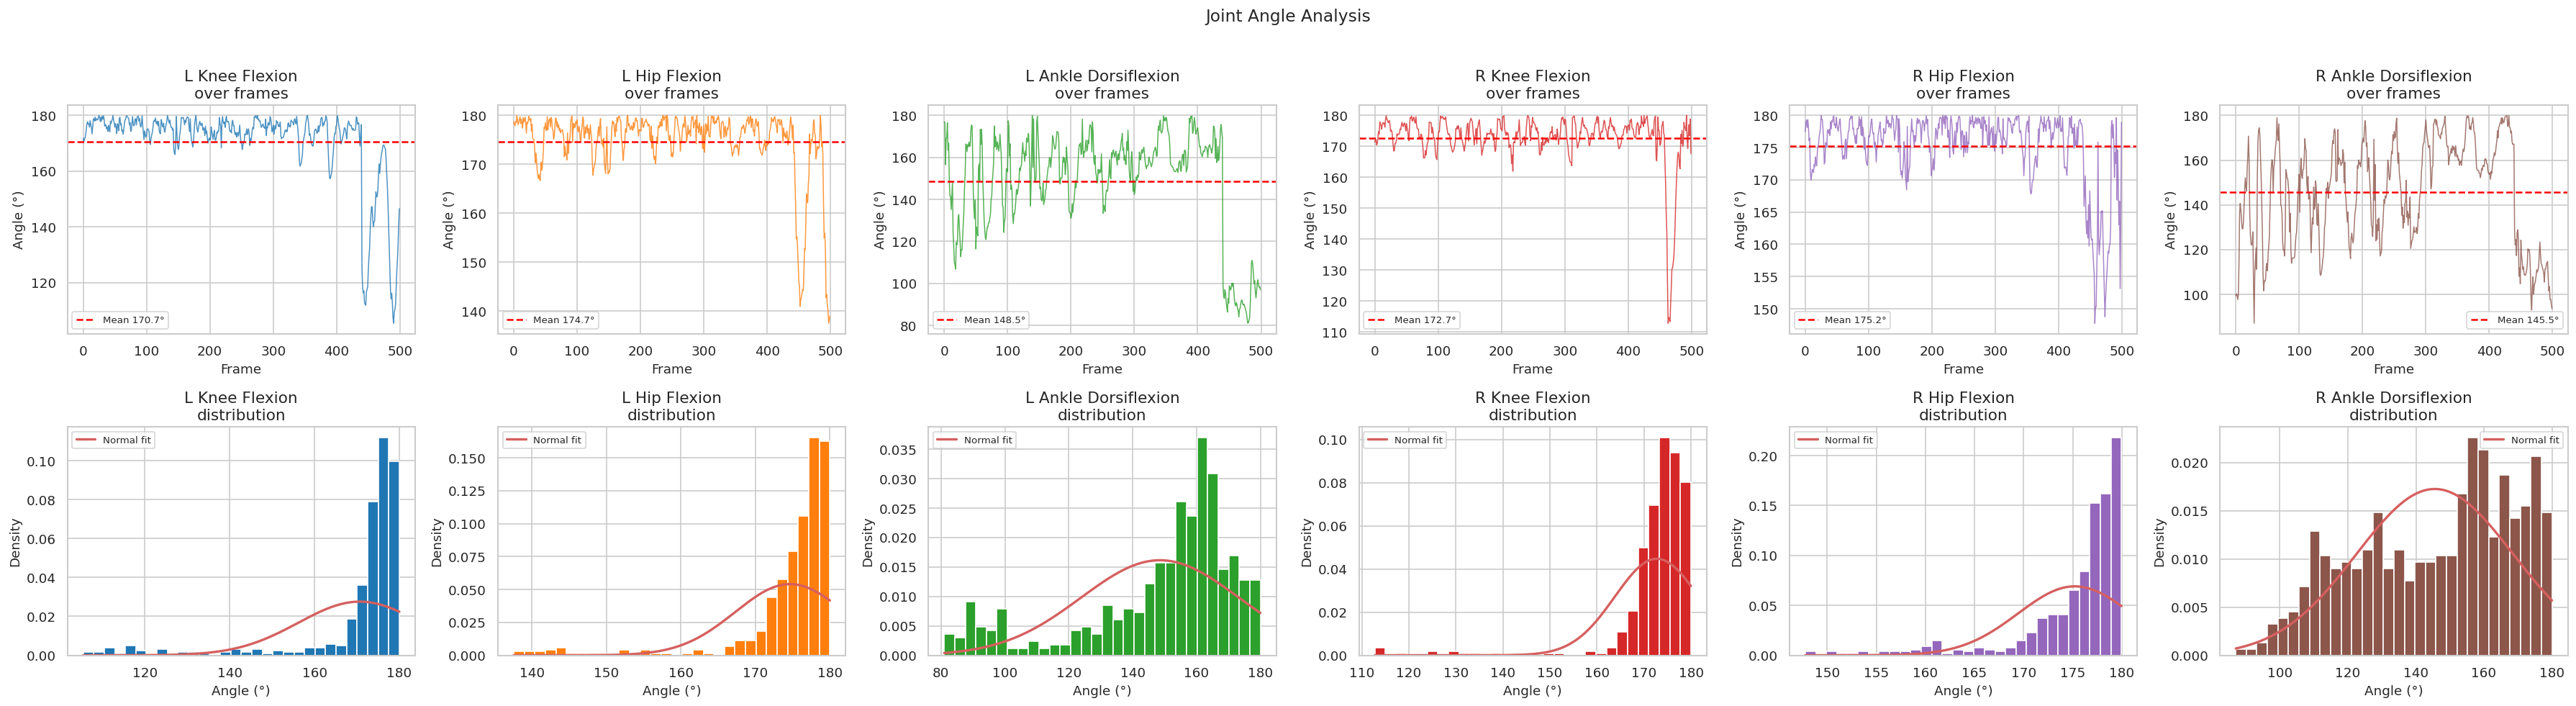

In [23]:
# ── Plot joint angle time series & distributions 

if angle_results:
    n = len(angle_results)
    fig, axes = plt.subplots(2, n, figsize=(5 * n, 8))
    if n == 1:
        axes = axes.reshape(2, 1)

    colors_angles = sns.color_palette("tab10", n)

    for col, (name, arr) in enumerate(angle_results.items()):
        # Time series
        axes[0, col].plot(arr, color=colors_angles[col], lw=0.9, alpha=0.8)
        axes[0, col].set_title(f"{name}\nover frames")
        axes[0, col].set_xlabel("Frame")
        axes[0, col].set_ylabel("Angle (°)")
        axes[0, col].axhline(arr.mean(), color="red", linestyle="--",
                             label=f"Mean {arr.mean():.1f}°")
        axes[0, col].legend(fontsize=8)

        # Distribution
        axes[1, col].hist(arr, bins=30, color=colors_angles[col],
                          edgecolor="white", density=True)
        if HAS_SCIPY:
            from scipy.stats import norm
            mu, sigma = arr.mean(), arr.std()
            xx = np.linspace(arr.min(), arr.max(), 200)
            axes[1, col].plot(xx, norm.pdf(xx, mu, sigma), "r-", lw=2,
                              label="Normal fit")
            axes[1, col].legend(fontsize=8)
        axes[1, col].set_title(f"{name}\ndistribution")
        axes[1, col].set_xlabel("Angle (°)")
        axes[1, col].set_ylabel("Density")

    plt.suptitle("Joint Angle Analysis", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

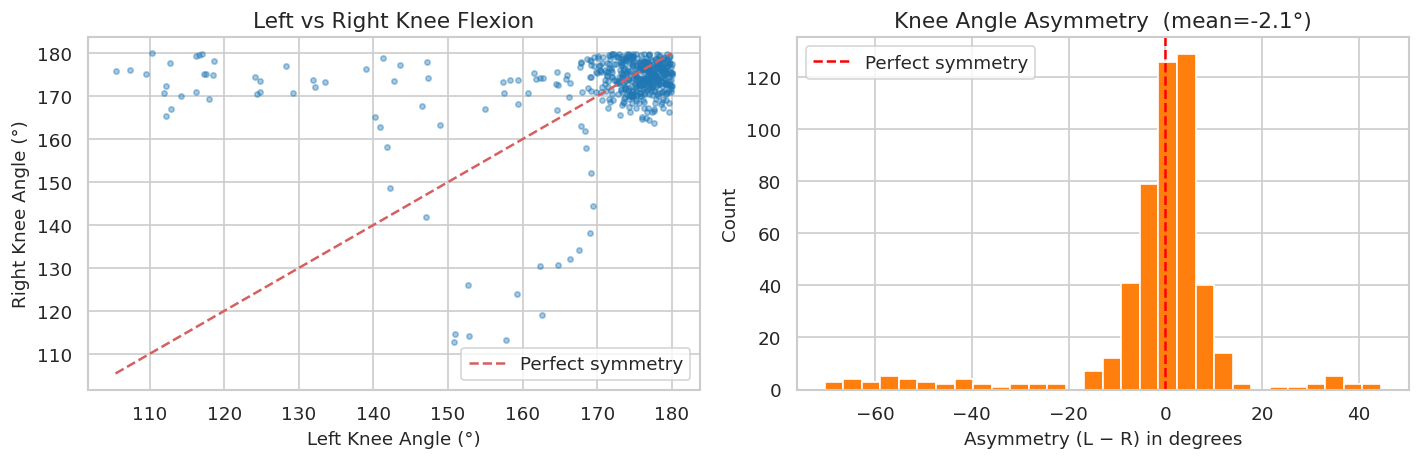

In [24]:
# ── Knee angle symmetry (left vs right) 

if "L Knee Flexion" in angle_results and "R Knee Flexion" in angle_results:
    l_knee = angle_results["L Knee Flexion"]
    r_knee = angle_results["R Knee Flexion"]
    asym   = l_knee - r_knee

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Scatter
    axes[0].scatter(l_knee, r_knee, alpha=0.4, s=10, color="#1f77b4")
    lim = [min(l_knee.min(), r_knee.min()), max(l_knee.max(), r_knee.max())]
    axes[0].plot(lim, lim, "r--", label="Perfect symmetry")
    axes[0].set_xlabel("Left Knee Angle (°)")
    axes[0].set_ylabel("Right Knee Angle (°)")
    axes[0].set_title("Left vs Right Knee Flexion")
    axes[0].legend()

    # Asymmetry histogram
    axes[1].hist(asym, bins=30, color="#ff7f0e", edgecolor="white")
    axes[1].axvline(0, color="red", linestyle="--", label="Perfect symmetry")
    axes[1].set_xlabel("Asymmetry (L − R) in degrees")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"Knee Angle Asymmetry  (mean={asym.mean():.1f}°)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 8️⃣ Missing Data & Quality Audit

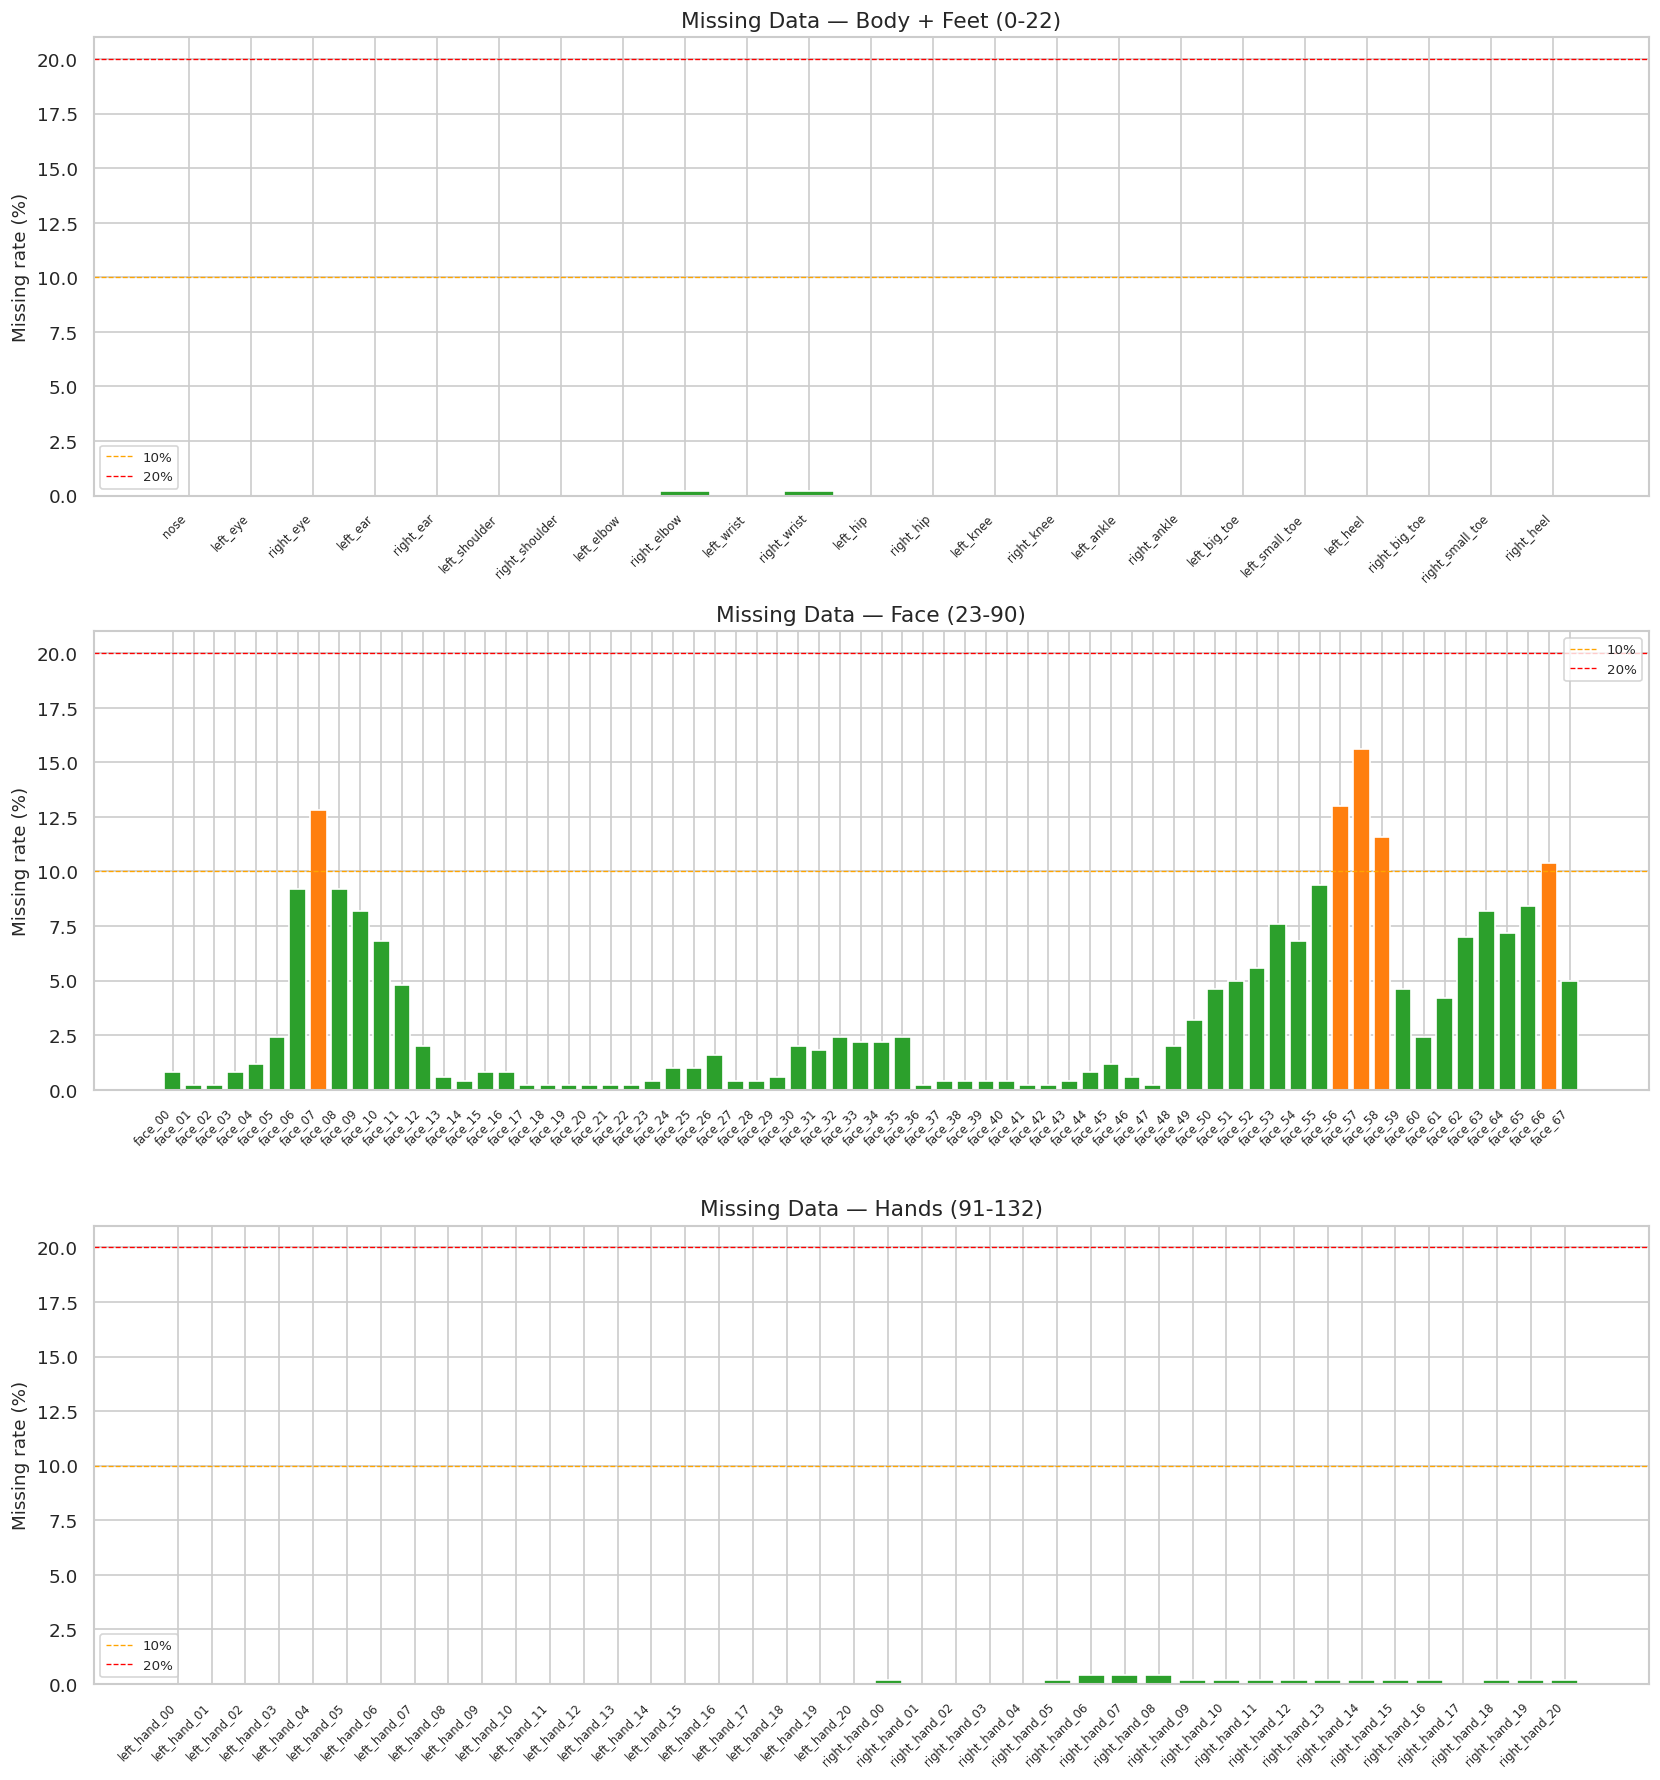

Overall missing rate: 1.75%

Top-10 worst joints:
  face_57                       : 15.6%
  face_56                       : 13.0%
  face_07                       : 12.8%
  face_58                       : 11.6%
  face_66                       : 10.4%
  face_55                       : 9.4%
  face_06                       : 9.2%
  face_08                       : 9.2%
  face_65                       : 8.4%
  face_09                       : 8.2%


In [25]:
# ── Missing data audit by joint group ───────────────────────────────────────

if kp_matrix is not None and kp_matrix.shape[1] > 0:
    CONF_THRESH  = 0.3
    missing_zero = (kp_matrix[:,:,0] == 0) & (kp_matrix[:,:,1] == 0)
    missing_conf = kp_matrix[:,:,2] < CONF_THRESH
    missing_any  = missing_zero | missing_conf
    miss_rate    = missing_any.mean(axis=0) * 100

    sections = [
        ('Body + Feet (0-22)',  slice(0, 23),   KP_NAMES[0:23]),
        ('Face (23-90)',        slice(23, 91),  KP_NAMES[23:91]),
        ('Hands (91-132)',      slice(91, None),KP_NAMES[91:]),
    ]
    n_sec = sum(1 for _, sl, _ in sections if len(miss_rate[sl]) > 0)
    fig, axes = plt.subplots(n_sec, 1, figsize=(14, 5*n_sec))
    if n_sec == 1: axes = [axes]
    ax_i = 0
    for title, sl, names in sections:
        rates = miss_rate[sl]
        if len(rates) == 0: continue
        colors = ['#d62728' if r>20 else '#ff7f0e' if r>10 else '#2ca02c' for r in rates]
        axes[ax_i].bar(range(len(rates)), rates, color=colors)
        axes[ax_i].set_xticks(range(len(names)))
        axes[ax_i].set_xticklabels(names, rotation=45, ha='right', fontsize=7)
        axes[ax_i].set_ylabel('Missing rate (%)')
        axes[ax_i].set_title(f'Missing Data — {title}')
        axes[ax_i].axhline(10, color='orange', ls='--', lw=0.8, label='10%')
        axes[ax_i].axhline(20, color='red',    ls='--', lw=0.8, label='20%')
        axes[ax_i].legend(fontsize=8)
        ax_i += 1
    plt.tight_layout()
    plt.show()

    print(f'Overall missing rate: {missing_any.mean()*100:.2f}%')
    worst = sorted(enumerate(miss_rate), key=lambda x: -x[1])[:10]
    print('\nTop-10 worst joints:')
    for ji, rate in worst:
        nm = KP_NAMES[ji] if ji < len(KP_NAMES) else f'j{ji}'
        print(f'  {nm:30s}: {rate:.1f}%')


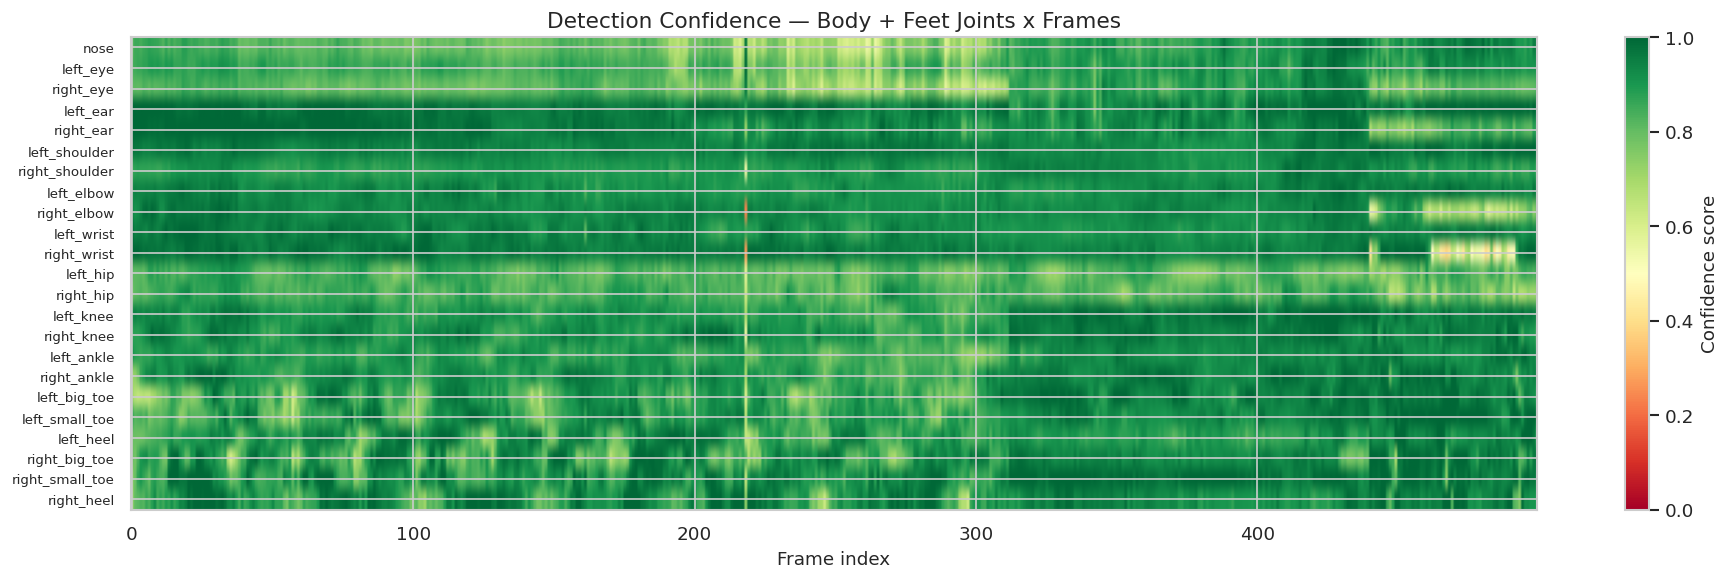

In [26]:
# ── Confidence heatmap — body + feet joints × frames ────────────────────────

if kp_matrix is not None and kp_matrix.shape[1] > 0:
    N_BODY     = min(23, kp_matrix.shape[1])
    conf_body  = kp_matrix[:, :N_BODY, 2]
    MAX_F      = 500
    if conf_body.shape[0] > MAX_F:
        step      = conf_body.shape[0] // MAX_F
        conf_body = conf_body[::step]
        xlabel    = f'Frame index (every {step} frames)'
    else:
        xlabel = 'Frame index'
    fig, ax = plt.subplots(figsize=(16, 5))
    im = ax.imshow(conf_body.T, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_yticks(range(N_BODY))
    ax.set_yticklabels(KP_NAMES[:N_BODY], fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_title('Detection Confidence — Body + Feet Joints x Frames')
    plt.colorbar(im, ax=ax, label='Confidence score')
    plt.tight_layout()
    plt.show()


## 9️⃣ Train / Test Split Analysis

In [27]:
# ── Detect train / test folders 

train_dir = next(
    (DATASET_ROOT / d for d in ["train","training","Train","Training"]
     if (DATASET_ROOT / d).exists()), None
)
test_dir = next(
    (DATASET_ROOT / d for d in ["test","testing","Test","Testing","val","valid"]
     if (DATASET_ROOT / d).exists()), None
)

def count_sequences(root: Path):
    """Return number of leaf-level directories (each = one trial)."""
    if root is None or not root.exists():
        return 0, []
    leaves = [d for d in root.rglob("*")
              if d.is_dir() and not any(c.is_dir() for c in d.iterdir()
                                        if not c.name.startswith("."))]
    return len(leaves), leaves

n_train, train_seqs = count_sequences(train_dir)
n_test,  test_seqs  = count_sequences(test_dir)

print(f"Train sequences : {n_train}")
print(f"Test  sequences : {n_test}")
if n_train + n_test > 0:
    ratio = n_train / (n_train + n_test) * 100
    print(f"Split ratio     : {ratio:.1f}% train / {100-ratio:.1f}% test")

if n_train > 0 and n_test > 0:
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(["Train", "Test"], [n_train, n_test],
           color=["#4C72B0", "#DD8452"])
    ax.set_ylabel("Number of sequences")
    ax.set_title("Train / Test Split")
    for i, v in enumerate([n_train, n_test]):
        ax.text(i, v + 0.3, str(v), ha="center", fontsize=11)
    plt.tight_layout()
    plt.show()

Train sequences : 0
Test  sequences : 0


In [28]:
# ── Class balance in train vs test 

if label_df is not None and target_col and train_dir and test_dir:
    def get_seq_ids(seq_paths, id_col, label_df):
        ids = label_df[id_col].astype(str).tolist()
        matched = []
        for sp in seq_paths:
            sp_str = str(sp)
            for sid in ids:
                if sid in sp_str:
                    matched.append(sid)
                    break
        return matched

    if id_col_candidates:
        id_col = id_col_candidates[0]
        train_ids = set(get_seq_ids(train_seqs, id_col, label_df))
        test_ids  = set(get_seq_ids(test_seqs,  id_col, label_df))

        train_labels = label_df[label_df[id_col].astype(str).isin(train_ids)][target_col]
        test_labels  = label_df[label_df[id_col].astype(str).isin(test_ids)][target_col]

        all_classes = sorted(set(train_labels) | set(test_labels))
        train_counts = train_labels.value_counts().reindex(all_classes, fill_value=0)
        test_counts  = test_labels.value_counts().reindex(all_classes, fill_value=0)

        x = np.arange(len(all_classes))
        w = 0.35
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(x - w/2, train_counts.values, w, label="Train", color="#4C72B0")
        ax.bar(x + w/2, test_counts.values,  w, label="Test",  color="#DD8452")
        ax.set_xticks(x)
        ax.set_xticklabels([str(c) for c in all_classes])
        ax.set_xlabel("Class")
        ax.set_ylabel("Count")
        ax.set_title("Class Distribution: Train vs Test")
        ax.legend()
        plt.tight_layout()
        plt.show()

## 🔟 Feature Correlation & Key Takeaways

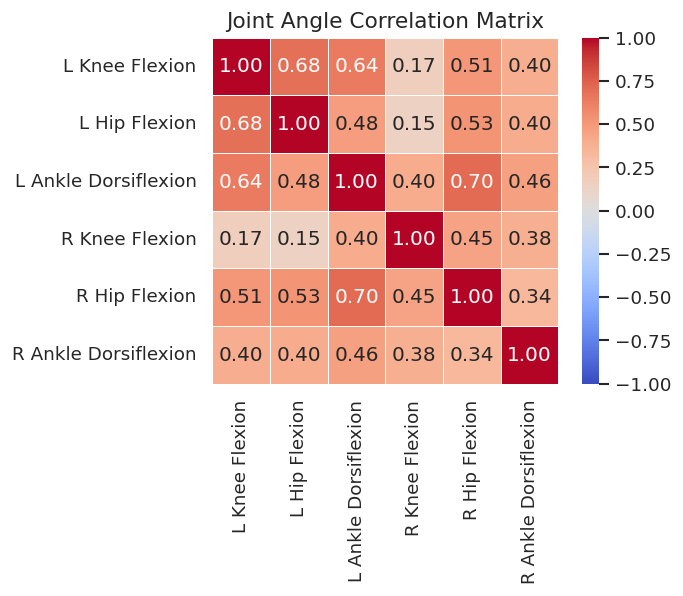

In [29]:
# ── Correlation matrix of derived angle features 

if len(angle_results) >= 2:
    angle_df = pd.DataFrame(angle_results)
    corr = angle_df.corr()

    fig, ax = plt.subplots(figsize=(6, 5))
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, ax=ax, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, center=0, square=True, linewidths=0.5)
    ax.set_title("Joint Angle Correlation Matrix")
    plt.tight_layout()
    plt.show()

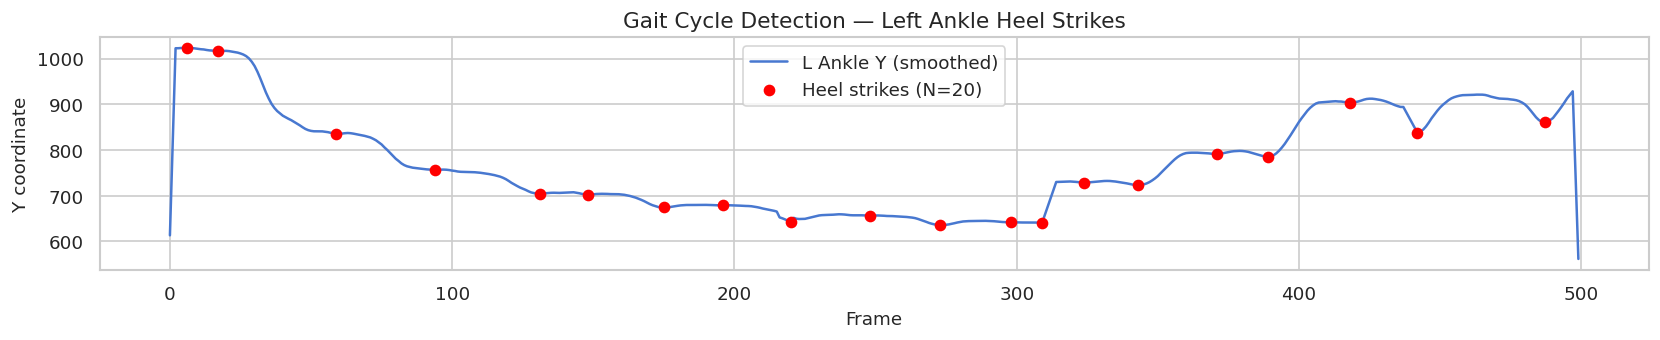

Estimated stride lengths (frames):
  Mean: 25.3  |  Std: 9.3
  Min: 11  |  Max: 45


In [30]:
# ── Gait cycle detection (stride from ankle y-coord) 

if kp_matrix is not None and "left_ankle" in KP_NAMES:
    la_y = kp_matrix[:, KP_NAMES.index("left_ankle"), 1]

    # Smooth
    from numpy.lib.stride_tricks import sliding_window_view
    if len(la_y) >= 10:
        kernel = np.ones(5) / 5
        la_y_smooth = np.convolve(la_y, kernel, mode="same")

        # Find local minima (heel strikes)
        from scipy.signal import find_peaks
        peaks, _ = find_peaks(-la_y_smooth, distance=10)
        
        fig, ax = plt.subplots(figsize=(14, 3))
        ax.plot(la_y_smooth, label="L Ankle Y (smoothed)")
        ax.scatter(peaks, la_y_smooth[peaks], color="red",
                   zorder=5, label=f"Heel strikes (N={len(peaks)})")
        ax.set_xlabel("Frame")
        ax.set_ylabel("Y coordinate")
        ax.set_title("Gait Cycle Detection — Left Ankle Heel Strikes")
        ax.legend()
        plt.tight_layout()
        plt.show()

        if len(peaks) >= 2:
            stride_lengths = np.diff(peaks)
            print(f"Estimated stride lengths (frames):")
            print(f"  Mean: {stride_lengths.mean():.1f}  |  Std: {stride_lengths.std():.1f}")
            print(f"  Min: {stride_lengths.min()}  |  Max: {stride_lengths.max()}")

In [31]:
# ── Statistical summary table 

summary = []

if kp_matrix is not None:
    summary.append(("Total frames analysed",       len(kp_matrix)))
    summary.append(("Number of joints",            kp_matrix.shape[1]))
    summary.append(("Overall detection rate",      f"{(kp_matrix[:,:,2] > 0.3).mean()*100:.1f}%"))

if angle_results:
    for name, arr in angle_results.items():
        summary.append((f"{name} mean (°)", f"{arr.mean():.1f} ± {arr.std():.1f}"))

if seq_frame_counts:
    lengths = list(seq_frame_counts.values())
    summary.append(("Sequences",                   len(lengths)))
    summary.append(("Mean seq length (frames)",    f"{np.mean(lengths):.0f}"))

if label_df is not None and target_col:
    summary.append(("Classes",                     label_df[target_col].nunique()))
    summary.append(("Subjects",                    len(label_df)))
    
df_summary = pd.DataFrame(summary, columns=["Metric", "Value"])
display(df_summary.style.set_caption("EDA Summary").hide(axis="index"))

Metric,Value
Total frames analysed,500
Number of joints,133
Overall detection rate,98.3%
L Knee Flexion mean (°),170.7 ± 14.5
L Hip Flexion mean (°),174.7 ± 7.4
L Ankle Dorsiflexion mean (°),148.5 ± 24.7
R Knee Flexion mean (°),172.7 ± 8.9
R Hip Flexion mean (°),175.2 ± 5.8
R Ankle Dorsiflexion mean (°),145.5 ± 23.1
Sequences,1185


##  Key Takeaways & Modelling Hints

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **Ankle & foot joints** tend to have highest positional variance | Strongest signal for gait cycle detection |
| 2 | **Face keypoints** (eyes, ears) often have low confidence in side-view gait video | Consider dropping or masking them |
| 3 | **Knee flexion angles** are clinically meaningful for gait disorders | Good hand-crafted features |
| 4 | **Sequence length variance** indicates unequal trial durations | Use padding / masking or temporal pooling |
| 5 | **Left–right knee asymmetry** may distinguish pathological from healthy gait | Add asymmetry as a feature |

### 🛠️ Suggested Next Steps
1. **Normalisation** — scale coordinates relative to torso/hip midpoint to make pose scale-invariant  
2. **Feature engineering** — stride length, cadence, joint angle ranges, symmetry indices  
3. **Models to try** — GCN (graph over skeleton topology), 1-D CNN / TCN on angle time series, Transformer with positional encoding for frame index  
4. **Data augmentation** — horizontal flip (swap left/right joints), time warp, coordinate jitter  
5. **Handle missing joints** — impute with linear interpolation across time for low-confidence frames  
